# 01-analysis — AI News Sentiment Pipeline

This notebook runs the following pipeline:

1. Load API key from `.env` (`NEWS_API_KEY`)
2. Fetch news with `fetch_news.NewsFetcher`
3. Preprocess text with `preprocess.Preprocessor`
4. Sentiment analysis with 2 different sentiment models `sentiment_model.SentimentModel1` and `sentiment_model.SentimentModel2` (lexicon baseline)
5. Evaluation the results with `evaluation.Evaluator` (no files as output, notebook-only)

*If the API call fails (no internet / invalid key), the notebook uses small **fallback texts** to test the pipeline.*

In [14]:
# imports
import os
from pathlib import Path
from dotenv import load_dotenv

# Local modules
from src.fetch_news import NewsFetcher
from src.preprocess import Preprocessor
from src.sentiment_model import SentimentModel1
from src.sentiment_model import SentimentModel2 # lexicon model with NLTK fallback
from src.evaluation import Evaluator

import pandas as pd
import matplotlib.pyplot as plt

## 1) Load API key (`.env`)
The key is read from `NEWS_API_KEY`.

In [15]:
# try to load from the project's folder (adjust if .env is kept elsewhere)
env_path = Path("env/.env") # change or remove if not used
if env_path.exists():
    print("Found env at:", env_path)
    load_dotenv(dotenv_path=env_path)
else:
    load_dotenv() # search default locations

api_key = os.getenv("NEWS_API_KEY")
print("Found NEWS_API_KEY?", bool(api_key))

Found NEWS_API_KEY? True


## 2) Fetch news (`fetch_news.NewsFetcher`)

Default query: `"AI"` (or `"artificial intelligence"`).
If fetching fails or returns no items, small fallback texts are used.

In [16]:
texts: list[str] = []
error = None

try:
    fetcher = NewsFetcher(query="AI", language="en", page_size=100)
    articles = fetcher.fetch() # list[dict] with keys like title/description/content/url/...
    if not articles:
        raise RuntimeError("API returned no articles.")

    # combine fields into a single text per article (title + description/content)
    def to_text(a):
        title = a.get("title") or ""
        desc = a.get("description") or ""
        cont = a.get("content") or ""
        combo = " ".join([title, desc or cont]).strip()
        return combo

    texts = [to_text(a) for a in articles if to_text(a)]
    if not texts:
        raise RuntimeError("Articles had no usable text.")
except Exception as e:
    error = e
    # fallback examples
    texts = [
        "AI brings amazing progress and innovation!",
        "There are serious concerns about data privacy risks.",
        "Mixed opinions about how AI will affect jobs.",
        "AI development seems neutral overall."
    ]

print(f"Total texts: {len(texts)}")
if error:
    print("Note: API fetch failed, fallback examples are used.")
    print("Error:", error)

... ₍^. .^₎⟆ Fetching latest news about 'AI' ...
Fetched 99 articles successfully ദ്ദി/ᐠ｡‸｡ᐟ\!
Total texts: 99


## 3) Preprocessing (`preprocess.Preprocessor`)
Light cleanup: trim spaces and replace newlines.
(This class can be improved / extended later with more robust cleaning as needed.)

In [17]:
preprocessed = Preprocessor(texts)
clean_texts = preprocessed.clean()

pd.DataFrame({"text": clean_texts}).head(15)

,text
0,Waverly Advisors Makes Back-to-Back Acquisitio...
1,L18-Powered 1971 Datsun 510 2-Door Sedan Race ...
2,Nasdaq leading U.S. stocks sharply lower in fi...
3,Ignoring Long COVID and Neurodivergence Is an ...
4,OpenAI Brings Sora Video-Generating App to And...
5,Anthropic Banks on Increased AI Demand for 28%...
6,Papa John’s Stock Tumbles on Report That Apoll...
7,Bitcoin Falls Amid Investor Concerns About Ste...
8,Union reaches pay deal with London underground...
9,Rises after Selling Control of Its China Busin...


## 4) Sentiment analysis:

- `sentiment_model.SentimentModel1`
- `sentiment_model.SentimentModel2` (baseline lexicon model)

These models return probabilities per class via `predict_proba` and labels via `predict`.

In [18]:
model1 = SentimentModel1()
probs1 = model1.predict_proba(clean_texts) # list of {'pos': p, 'neu': p, 'neg': p}
labels1 = model1.predict(clean_texts) # list of 'pos' | 'neu' | 'neg'

# build a tidy results DataFrame for quick inspection
print("---- Results from sentiment model 1's analysis: ----\n")
print("Probabilities:\n", probs1)
print("\nLabels:\n", labels1)
df_results_model1 = pd.DataFrame(probs1)
df_results_model1["label"] = labels1
df_results_model1["text"]  = clean_texts
df_results_model1.head()

---- Results from sentiment model 1's analysis: ----

Probabilities:
 [{'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.9999995000005, 'neu': 0.0, 'neg': 4.999995000004999e-07}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.999999000002, 'neu': 0.0, 'neg': 9.99998000004e-07}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, {'pos': 0.5, 'neu': 0.0, 'neg': 0.5}, 

,pos,neu,neg,label,text
0,0.5,0.0,0.5,neu,Waverly Advisors Makes Back-to-Back Acquisitio...
1,0.5,0.0,0.5,neu,L18-Powered 1971 Datsun 510 2-Door Sedan Race ...
2,0.5,0.0,0.5,neu,Nasdaq leading U.S. stocks sharply lower in fi...
3,0.5,0.0,0.5,neu,Ignoring Long COVID and Neurodivergence Is an ...
4,0.5,0.0,0.5,neu,OpenAI Brings Sora Video-Generating App to And...


In [19]:
model2 = SentimentModel2()  # uses NLTK opinion lexicon if available; otherwise fallback lists
probs2 = model2.predict_proba(clean_texts)  # list of {'pos': p, 'neu': p, 'neg': p}
labels2 = model2.predict(clean_texts)       # list of 'pos' | 'neu' | 'neg'

# Build a tidy results DataFrame for quick inspection
print("---- Results from sentiment model 2's analysis: ----\n")
print("Probabilities:\n", probs2)
print("\nLabels:\n", labels2)
df_results_model2 = pd.DataFrame(probs2)
df_results_model2["label"] = labels2
df_results_model2["text"]  = clean_texts
df_results_model2.head()

Could not load NLTK opinion lexicon — using fallback lists.
---- Results from sentiment model 2's analysis: ----

Probabilities:
 [{'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 1.0, 'neu': 0.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 0.0, 'neg': 1.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 1.0, 'neu': 0.0, 'neg': 0.0}, {'pos': 1.0, 'neu': 0.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0.0}, {'pos': 0.0, 'neu': 1.0, 'neg': 0

,pos,neu,neg,label,text
0,0.0,0.0,1.0,neg,Waverly Advisors Makes Back-to-Back Acquisitio...
1,0.0,1.0,0.0,neu,L18-Powered 1971 Datsun 510 2-Door Sedan Race ...
2,0.0,0.0,1.0,neg,Nasdaq leading U.S. stocks sharply lower in fi...
3,0.0,1.0,0.0,neu,Ignoring Long COVID and Neurodivergence Is an ...
4,0.0,0.0,1.0,neg,OpenAI Brings Sora Video-Generating App to And...


## 5) Evaluation (`evaluation.Evaluator`)
Notebook-friendly summaries: average scores, label distribution, and top positive / negative texts.

--- Evaluating the results from sentiment model 1's analysis: ---

   pos  neu  neg label                                               text
0  0.5  0.0  0.5   neu  Waverly Advisors Makes Back-to-Back Acquisitio...
1  0.5  0.0  0.5   neu  L18-Powered 1971 Datsun 510 2-Door Sedan Race ...
2  0.5  0.0  0.5   neu  Nasdaq leading U.S. stocks sharply lower in fi...
3  0.5  0.0  0.5   neu  Ignoring Long COVID and Neurodivergence Is an ...
4  0.5  0.0  0.5   neu  OpenAI Brings Sora Video-Generating App to And...

--- Average scores ---
{'pos': 0.5151514848485454, 'neu': 0.0, 'neg': 0.48484851515145455}

--- Label distribution ---


,sentiment,count,share
0,pos,96,0.97
1,neg,3,0.03


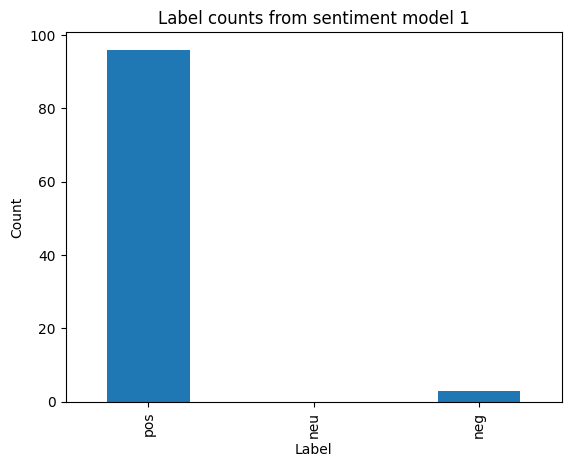


--- Top positive texts from sentiment model 1's analysis: ---



,pos,neu,neg,text
72,1.000000,0.0,4.999995e-07,Anthropic Banks on Increased AI Demand for 28%...
5,1.000000,0.0,4.999995e-07,Anthropic Banks on Increased AI Demand for 28%...
90,0.999999,0.0,9.999980e-07,Gensmo Brings Fashion Week AI Innovation into ...
42,0.999999,0.0,9.999980e-07,Media Briefing: HII and Incat Crowther of Sydn...
27,0.999999,0.0,9.999980e-07,Australia’s Economy Is Suddenly in Too Good a ...



--- Top negative texts from sentiment model 1's analysis: ---



,pos,neu,neg,text
49,4.999995e-07,0.0,1.000000,Unlocking Modern Risk & Compliance with Moody’...
31,4.999995e-07,0.0,1.000000,Inside the enterprise AI wall: Building contex...
75,9.999980e-07,0.0,0.999999,Qualcomm Set To Supply 90% Of iPhone 17 Modems...
62,5.000000e-01,0.0,0.500000,New ATO division to de-risk major system trans...
70,5.000000e-01,0.0,0.500000,Sigma Computing Grows by 28K SF at One Madison...


In [20]:
print("--- Evaluating the results from sentiment model 1's analysis: ---\n")
print(df_results_model1.head())
ev1 = Evaluator(probs1)

print("\n--- Average scores ---")
print(ev1.average_scores())

print("\n--- Label distribution ---")
dist1 = ev1.overall_distribution()
display(dist1)

# Bar chart of label counts
plt.figure()
(dist1.set_index("sentiment")["count"]
     .reindex(["pos","neu","neg"])
     .plot(kind="bar"))
plt.title("Label counts from sentiment model 1")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print("\n--- Top positive texts from sentiment model 1's analysis: ---\n")
display(ev1.top_positive(clean_texts, n=5))

print("\n--- Top negative texts from sentiment model 1's analysis: ---\n")
display(ev1.top_negative(clean_texts, n=5))

--- Evaluating the results from sentiment model 2's analysis: ---

   pos  neu  neg label                                               text
0  0.0  0.0  1.0   neg  Waverly Advisors Makes Back-to-Back Acquisitio...
1  0.0  1.0  0.0   neu  L18-Powered 1971 Datsun 510 2-Door Sedan Race ...
2  0.0  0.0  1.0   neg  Nasdaq leading U.S. stocks sharply lower in fi...
3  0.0  1.0  0.0   neu  Ignoring Long COVID and Neurodivergence Is an ...
4  0.0  0.0  1.0   neg  OpenAI Brings Sora Video-Generating App to And...

--- Average scores ---
{'pos': 0.08131313131313132, 'neu': 0.7278275034126288, 'neg': 0.1908593652742398}

--- Label distribution ---


,sentiment,count,share
0,neu,72,0.727
1,neg,19,0.192
2,pos,8,0.081


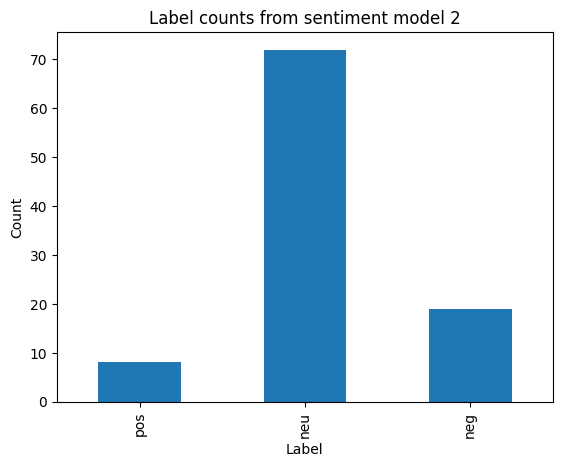


--- Top positive texts from sentiment model 2's analysis: ---



,pos,neu,neg,text
14,1.0,0.0,0.0,AMD Confirms RDSEED Security Flaw In Zen 5 CPU...
90,1.0,0.0,0.0,Gensmo Brings Fashion Week AI Innovation into ...
83,1.0,0.0,0.0,Here's What Wall Street Analysts Are Saying Ab...
40,1.0,0.0,0.0,"TextWisely – Write 10x Better: Reply emails, R..."
15,1.0,0.0,0.0,Bitcoin Miner MARA Revenue Hit Record High in ...



--- Top negative texts from sentiment model 2's analysis: ---



,pos,neu,neg,text
0,0.0,0.0,1.0,Waverly Advisors Makes Back-to-Back Acquisitio...
23,0.0,0.0,1.0,Trump administration considers revoking ban on...
25,0.0,0.0,1.0,EU plans December announcement to make small E...
26,0.0,0.0,1.0,Virginia governor’s race will test Trump and D...
28,0.0,0.0,1.0,Why Is the Dollar Index Stuck in Neutral? { wi...


In [21]:
print("--- Evaluating the results from sentiment model 2's analysis: ---\n")
print(df_results_model2.head())
ev2 = Evaluator(probs2)

print("\n--- Average scores ---")
print(ev2.average_scores())

print("\n--- Label distribution ---")
dist2 = ev2.overall_distribution()
display(dist2)

# Bar chart of label counts
plt.figure()
(dist2.set_index("sentiment")["count"]
     .reindex(["pos","neu","neg"])
     .plot(kind="bar"))
plt.title("Label counts from sentiment model 2")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print("\n--- Top positive texts from sentiment model 2's analysis: ---\n")
display(ev2.top_positive(clean_texts, n=5))

print("\n--- Top negative texts from sentiment model 2's analysis: ---\n")
display(ev2.top_negative(clean_texts, n=5))

### Architecture notes
- **Modularity:** separate components with:
    - `fetch_news.py`
    - `preprocess.py`
    - Sentiment analysis with 2 different sentiment models:
        - `sentiment_model.SentimentModel1`
        - `sentiment_model.SentimentModel2`
    - `evaluation.py`
- **Swapability:** replacable data sources (NewsAPI / scraper) or analysis models without changing the notebook logic.
- **Extensions:** logging, caching responses, richer preprocessing, database storage, dashboards / plots, CI + tests.